# AlexNet Training and Competition: Gradience vs. PyTorch on CIFAR-10

This notebook demonstrates the newly added 2D Pooling (`MaxPool2D`, `AdaptiveAvgPool2D`) and Reshaping/Flattening capabilities in the **Gradience** framework. We build the canonical **AlexNet** model from first principles and put it in a step-by-step mathematical and performance competition against PyTorch using the **CIFAR-10** dataset.

## 1. Imports and Setup

In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from gradience.tensor import Tensor
from gradience.nn.models.alexnet import AlexNet
from gradience.nn.losses.cross_entropy import CrossEntropyLoss
from gradience.optim.sgd import SGD

## 2. Define the PyTorch Counterpart
To confirm mathematical identicality, we define the exact structural equivalent in PyTorch and write a helper function to synchronize their weights memory-for-memory.

In [8]:
class PtAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def copy_weights(pt_model, gr_model):
    conv_indices = [0, 3, 6, 8, 10]
    for idx in conv_indices:
        pt_conv = pt_model.features[idx]
        gr_conv = gr_model.features[idx]
        gr_conv.weight.data[...] = pt_conv.weight.cpu().detach().numpy()
        if gr_conv.bias is not None:
            gr_conv.bias.data[...] = pt_conv.bias.cpu().detach().numpy()

    linear_indices = [1, 4, 6]
    for idx in linear_indices:
        pt_linear = pt_model.classifier[idx]
        gr_linear = gr_model.classifier[idx]
        gr_linear.weight.data[...] = pt_linear.weight.cpu().detach().numpy().T
        if gr_linear.bias is not None:
            gr_linear.bias.data[...] = pt_linear.bias.cpu().detach().numpy()

## 3. CIFAR-10 Dataset Loading & Processing

In [9]:
np.random.seed(42)
torch.manual_seed(42)

num_classes = 10
batch_size = 4
height, width = 64, 64

transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

X_list = []
y_list = []
for idx in range(32):
    img_tensor, label = cifar_train[idx]
    X_list.append(img_tensor.numpy())
    y_list.append(label)

X_data = np.stack(X_list, axis=0).astype(np.float64)
y_data = np.array(y_list)
y_data_oh = np.eye(num_classes)[y_data]

print(f"Dataset shape: {X_data.shape}")
print(f"Labels shape:  {y_data_oh.shape}")

100.0%


Dataset shape: (32, 3, 64, 64)
Labels shape:  (32, 10)


## 4. Framework Competition: Single Step Execution & Verification
We load both models, synchronize weights, run a forward/backward pass, and evaluate absolute difference tolerances and execution times.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch Device: {device}")

gr_model = AlexNet(num_classes=num_classes)
pt_model = PtAlexNet(num_classes=num_classes).double().to(device)
copy_weights(pt_model, gr_model)

gr_model.eval()
pt_model.eval()

x_pt = torch.tensor(X_data[:batch_size], requires_grad=True, dtype=torch.float64, device=device)
x_gr = Tensor(X_data[:batch_size], requires_grad=True)

y_pt_oh = torch.tensor(y_data_oh[:batch_size], dtype=torch.float64, device=device)
y_gr_oh = Tensor(y_data_oh[:batch_size])

t0 = time.time()
out_pt = pt_model(x_pt)
loss_pt = ((out_pt - y_pt_oh) ** 2).mean()
pt_fwd_time = time.time() - t0

t0 = time.time()
loss_pt.backward()
pt_bwd_time = time.time() - t0

t0 = time.time()
out_gr = gr_model(x_gr)
loss_gr = ((out_gr - y_gr_oh) ** 2).mean()
gr_fwd_time = time.time() - t0

t0 = time.time()
loss_gr.backward()
gr_bwd_time = time.time() - t0

max_out_diff = np.max(np.abs(out_gr.data - out_pt.cpu().detach().numpy()))
max_loss_diff = np.abs(loss_gr.item() - loss_pt.item())
max_grad_x_diff = np.max(np.abs(x_gr.grad - x_pt.grad.cpu().numpy()))

pt_conv1_grad = pt_model.features[0].weight.grad.cpu().numpy()
gr_conv1_grad = gr_model.features[0].weight.grad
max_conv1_grad_diff = np.max(np.abs(gr_conv1_grad - pt_conv1_grad))

print(f"--- Mathematical Verification ---")
print(f"Max difference in output logits: {max_out_diff:.2e}")
print(f"Difference in loss values: {max_loss_diff:.2e}")
print(f"Max difference in input gradients (dx): {max_grad_x_diff:.2e}")
print(f"Max difference in Conv1 weight gradients: {max_conv1_grad_diff:.2e}")

print(f"\n--- Performance Competition ---")
print(f"PyTorch Forward Pass:   {pt_fwd_time*1000:.2f} ms")
print(f"Gradience Forward Pass: {gr_fwd_time*1000:.2f} ms")
print(f"PyTorch Backward Pass:  {pt_bwd_time*1000:.2f} ms")
print(f"Gradience Backward Pass: {gr_bwd_time*1000:.2f} ms")

Using PyTorch Device: cuda
--- Mathematical Verification ---
Max difference in output logits: 2.26e-17
Difference in loss values: 0.00e+00
Max difference in input gradients (dx): 6.14e-21
Max difference in Conv1 weight gradients: 5.93e-20

--- Performance Competition ---
PyTorch Forward Pass:   288.41 ms
Gradience Forward Pass: 763.96 ms
PyTorch Backward Pass:  103.04 ms
Gradience Backward Pass: 1604.69 ms


## 5. Mini Training Loop & Convergence Comparison
We run a 5-epoch training loop to demonstrate that our framework's optimization parameters update identically to PyTorch's native `SGD` engine. We plot the resulting loss curves.

In [11]:
gr_model = AlexNet(num_classes=num_classes)
pt_model = PtAlexNet(num_classes=num_classes).double().to(device)
copy_weights(pt_model, gr_model)

gr_model.eval()
pt_model.eval()

lr = 0.01
gr_opt = SGD(gr_model.parameters(), lr=lr)
pt_opt = torch.optim.SGD(pt_model.parameters(), lr=lr)

gr_losses = []
pt_losses = []

for epoch in range(5):
    epoch_gr_loss = 0.0
    epoch_pt_loss = 0.0
    
    for i in range(0, len(X_data), batch_size):
        xb = X_data[i:i+batch_size]
        yb = y_data_oh[i:i+batch_size]
        
        # PyTorch update
        xb_pt = torch.tensor(xb, dtype=torch.float64, device=device)
        yb_pt = torch.tensor(yb, dtype=torch.float64, device=device)
        pt_opt.zero_grad()
        out_pt = pt_model(xb_pt)
        loss_pt = ((out_pt - yb_pt) ** 2).mean()
        loss_pt.backward()
        pt_opt.step()
        epoch_pt_loss += loss_pt.item()
        
        # Gradience update
        xb_gr = Tensor(xb)
        yb_gr = Tensor(yb)
        gr_opt.zero_grad()
        out_gr = gr_model(xb_gr)
        loss_gr = ((out_gr - yb_gr) ** 2).mean()
        loss_gr.backward()
        gr_opt.step()
        epoch_gr_loss += loss_gr.item()
        
    gr_losses.append(epoch_gr_loss / 8.0)
    pt_losses.append(epoch_pt_loss / 8.0)
    print(f"Epoch {epoch+1} | Gradience Loss: {gr_losses[-1]:.6f} | PyTorch Loss: {pt_losses[-1]:.6f}")

Epoch 1 | Gradience Loss: 0.099597 | PyTorch Loss: 0.099597
Epoch 2 | Gradience Loss: 0.099012 | PyTorch Loss: 0.099012
Epoch 3 | Gradience Loss: 0.098455 | PyTorch Loss: 0.098455
Epoch 4 | Gradience Loss: 0.097926 | PyTorch Loss: 0.097926
Epoch 5 | Gradience Loss: 0.097421 | PyTorch Loss: 0.097421


## 6. Plot Loss Convergence

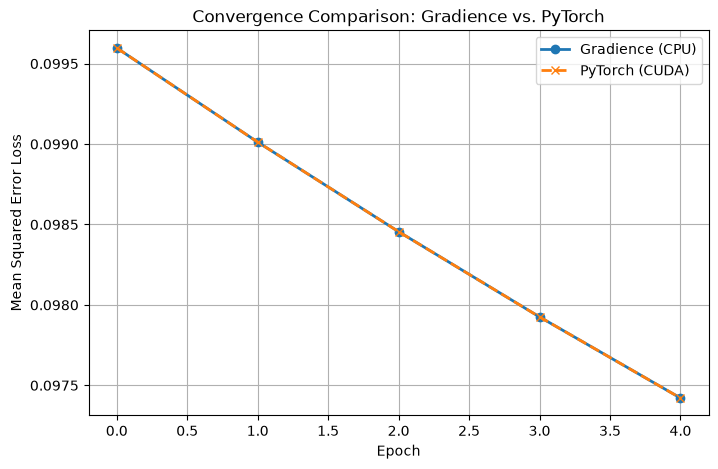

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(gr_losses, label="Gradience (CPU)", marker="o", linewidth=2)
plt.plot(pt_losses, label=f"PyTorch ({device.type.upper()})", linestyle="--", marker="x", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.title("Convergence Comparison: Gradience vs. PyTorch")
plt.legend()
plt.grid(True)
plt.savefig("alexnet_convergence.png")
plt.show()